## **Task 1. Data analysis**
**Points: 2**

**Make a thorough analysis of the data. Some possible questions to answer include (but is not limited to):**
• What patterns exist within the individual series?
• What relationships exist between the different series?
• Can the series be grouped? If so, indicate which groups you believe exist.

<br>
What other questions can you ask and answer? Extract as much information as you can and keep a critical mindset. It may be relevant to consider the returns of the price series, i.e., the change in price from one day to the next relative to the price itself (or alternatively the log-returns). While it is possible that the absolute price levels also contain useful information, in this case, it is probably a good approach to primarily work with returns.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from time_series_analysis.utils import hello

In [55]:
df = pd.read_csv('../data/spiff_data-2.csv')

df

,Unnamed: 0,day,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
0,0,1,6.154653,2.794285,2.136536,10.653684,3.324896,3.896149,7.755880
1,1,2,6.189623,2.843068,2.113582,10.674465,3.355736,3.899915,7.781310
2,2,3,6.168641,2.839644,2.116336,10.822372,3.336461,3.897404,7.886205
3,3,4,6.156401,2.823384,2.096137,10.848804,3.288274,3.901170,7.848061
4,4,5,6.124929,2.832798,2.099810,10.860731,3.303694,3.905355,7.883026
...,...,...,...,...,...,...,...,...,...
5451,5451,5452,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5452,5452,5453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5453,5453,5454,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5454,5454,5455,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
counts_of_1000 = (df == 1000).sum()
print(counts_of_1000)

Unnamed: 0      1
day             1
gurkor          5
guitars         5
slingshots      5
stocks          5
sugar           5
water           5
tranquillity    5
dtype: int64


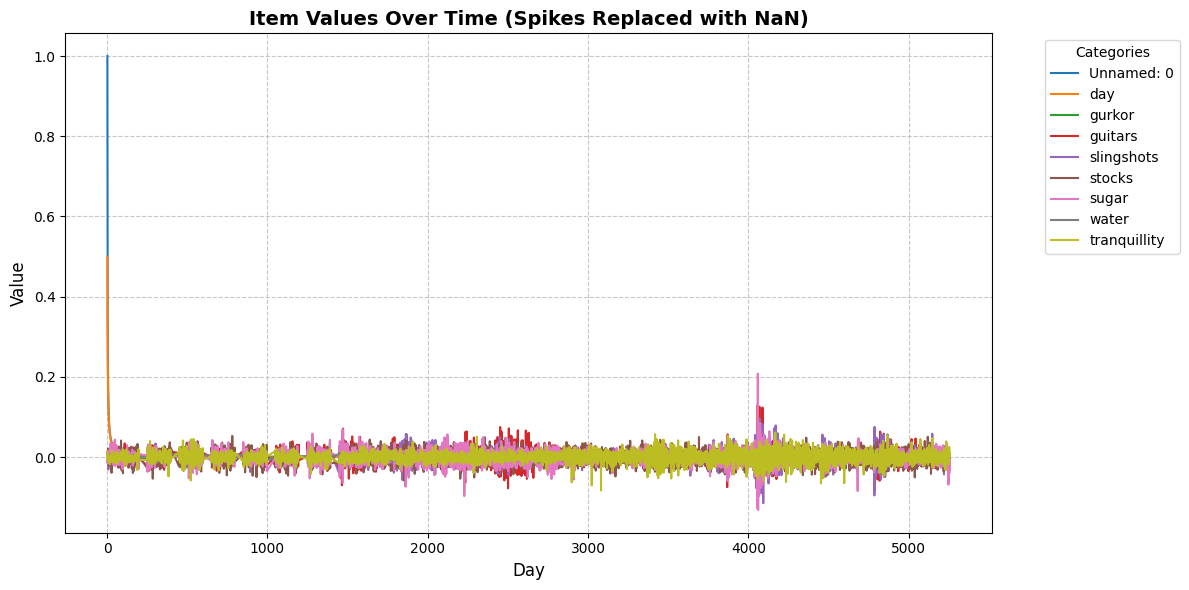

In [61]:

# 1. Replace all exact 1000s with NaN across the entire DataFrame
df_cleaned = df.replace(1000, np.nan)

# 2. Prep for plotting (drop the artifact column and set the index)
plot_df = df_cleaned.drop(columns=['Unnamed: 0']).set_index('day')
plot_df = (df_cleaned /df_cleaned.shift(1)-1).iloc[2:].dropna()

# 3. Plot the cleaned data
ax = plot_df.plot(figsize=(12, 6), linewidth=1.5)

# Customize the plot
ax.set_title('Item Values Over Time (Spikes Replaced with NaN)', fontsize=14, fontweight='bold')
ax.set_xlabel('Day', fontsize=12)
ax.set_ylabel('Value', fontsize=12)

# Move the legend outside the plot
plt.legend(title='Categories', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add a grid
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()

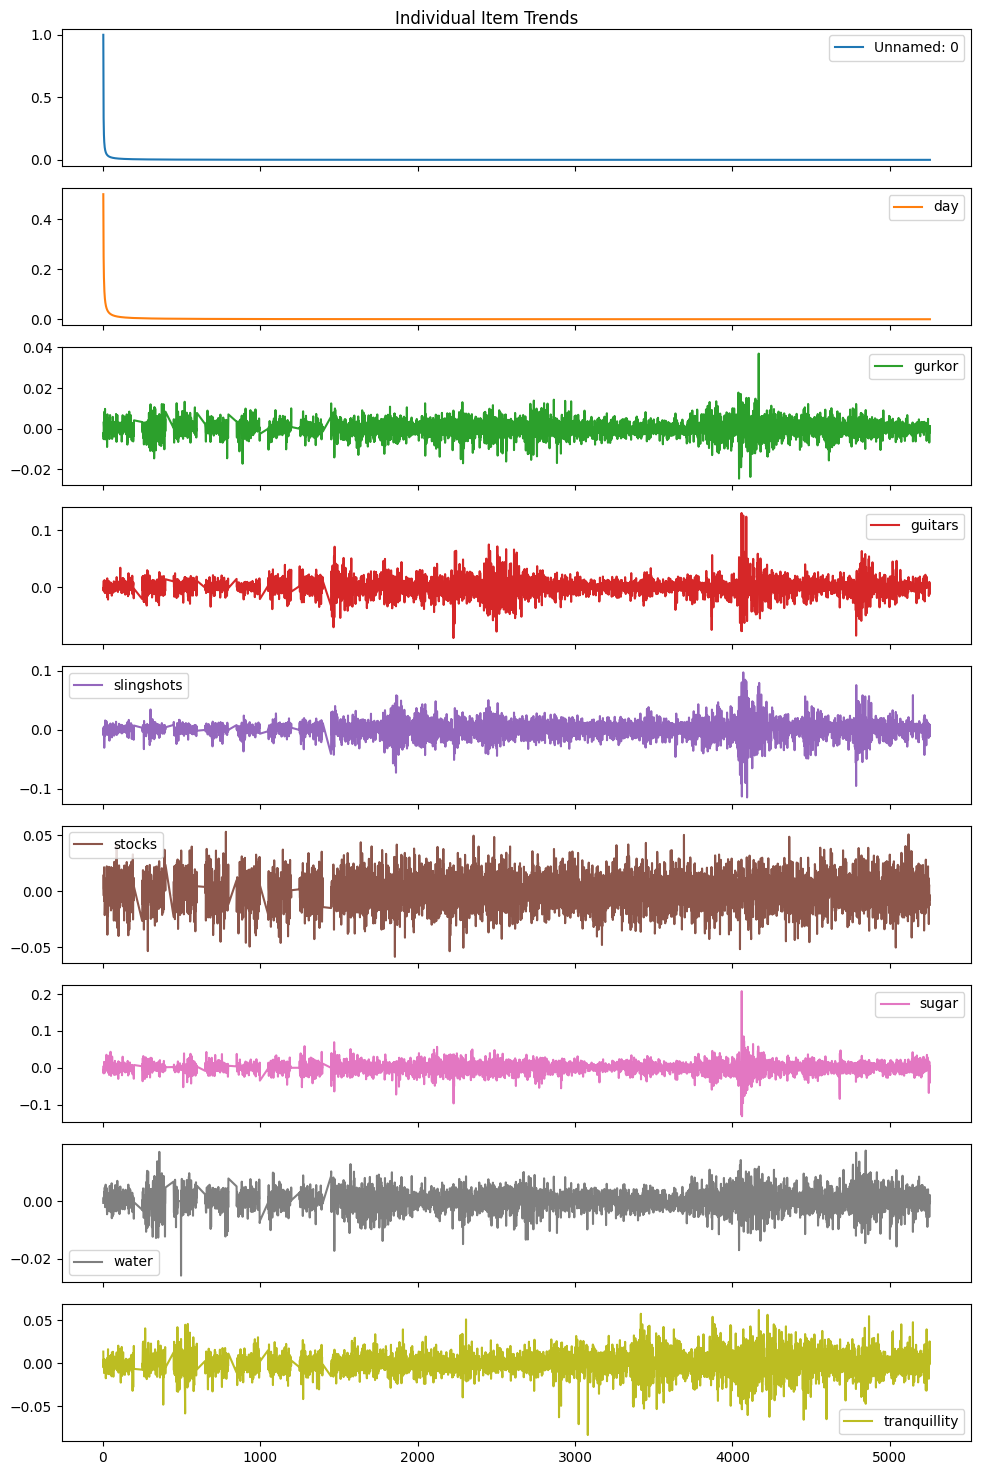

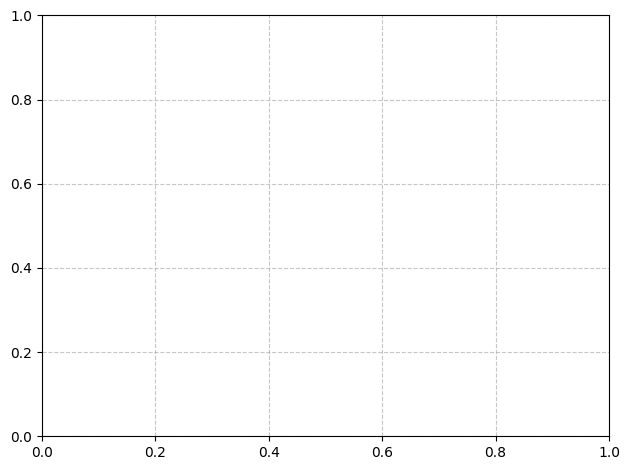

In [62]:

# 1. Clean up the DataFrame for plotting
# Drop the redundant index column and set 'day' as the new index

# 2. Plot the data
# A figure size of 12x6 gives a good wide view for time series data (~5400 days)
#ax = plot_df.plot(figsize=(12, 6), linewidth=1.5)
# Plots each column on its own dedicated Y-axis
plot_df.plot(subplots=True, figsize=(10, 15), title="Individual Item Trends")
plt.tight_layout()
plt.show()

# 3. Customize the labels and appearance
ax.set_title('Item Values Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Day', fontsize=12)
ax.set_ylabel('Value', fontsize=12)

# Move the legend outside the plot so it doesn't cover your data lines

# Add a grid for easier reading
plt.grid(True, linestyle='--', alpha=0.7)

# Adjust layout to ensure the legend isn't cut off
plt.tight_layout()



In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# This is after the last gap.
df_cleaned_dropped = df_cleaned.iloc[1450:]

# Drops the 5 NaN days
df_PCA = df_cleaned_dropped.dropna()

df_metadata = df_PCA.iloc[:, :2]  
df_features = df_PCA.iloc[:, 2:]


In [ ]:
# ==========================================
# 2. STANDARDIZATION (Critical for PCA)
# ==========================================
# PCA looks for variance. If one time series is measured in thousands and 
# another in decimals, the larger scale will dominate the PCA. 
# Standardization forces all 7 series to have a mean of 0 and variance of 1.
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_features)

In [ ]:
# ==========================================
# 3. FIT AND TRANSFORM THE PCA
# ==========================================
# Instantiating PCA without specifying n_components calculates all 7 components.
pca = PCA()
principal_components = pca.fit_transform(scaled_data)

# Create a clean DataFrame of your new Principal Components, keeping your time index
component_names = [f"PC{i+1}" for i in range(principal_components.shape[1])]
df_pca_components = pd.DataFrame(
    data=principal_components, 
    index=df_PCA.index, 
    columns=component_names
)

Explained Variance Ratio per Component:
PC1: 0.4355 (43.55%)
PC2: 0.3224 (32.24%)
PC3: 0.1356 (13.56%)
PC4: 0.0713 (7.13%)
PC5: 0.0251 (2.51%)
PC6: 0.0088 (0.88%)
PC7: 0.0012 (0.12%)

Cumulative Variance Explained by top 3 components: 89.35%


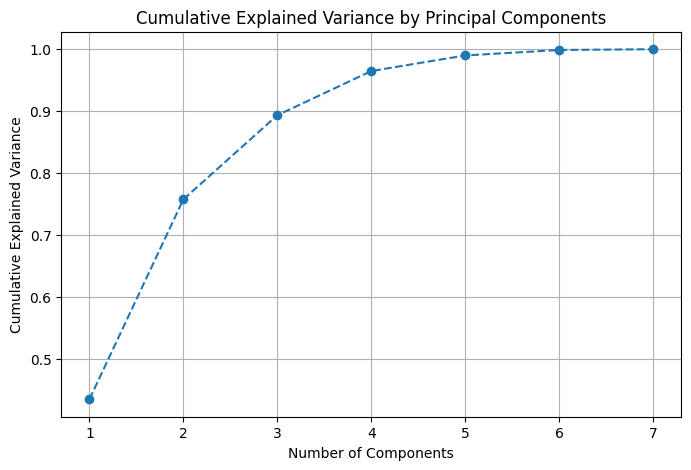

In [ ]:
# ==========================================
# 5. RECOMBINE METADATA WITH PCA RESULTS
# ==========================================
# Attach your 'index' and 'day' columns back to the principal components
df_final_pca = pd.concat([df_metadata, df_pca_components], axis=1)

# ==========================================
# 6. EVALUATE THE RESULTS
# ==========================================
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Explained Variance Ratio per Component:")
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")

print(f"\nCumulative Variance Explained by top 3 components: {cumulative_variance[2]*100:.2f}%")

# Optional: Plot the Scree Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, 8), cumulative_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by Principal Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

In [ ]:
# Extract the loadings
loadings = pd.DataFrame(
    pca.components_.T,  # Transpose the matrix
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=df_features.columns # Your original 7 column names
)

print("PCA Loadings (How much each series contributes to each PC):")
print(loadings)

PCA Loadings (How much each series contributes to each PC):
                   PC1       PC2       PC3       PC4       PC5       PC6  \
gurkor        0.510285 -0.278230 -0.073036 -0.156432 -0.048366 -0.396228   
guitars       0.095533  0.578251 -0.008029 -0.566643 -0.567472 -0.097050   
slingshots    0.510945  0.200522  0.263284 -0.091274  0.235159  0.737002   
stocks       -0.120149 -0.215775  0.941270 -0.108907 -0.113322 -0.166145   
sugar        -0.050177  0.627772  0.151122  0.057945  0.627043 -0.409172   
water         0.522168 -0.218032 -0.049712 -0.277889  0.263986 -0.265197   
tranquillity  0.424035  0.244561  0.118258  0.744092 -0.380293 -0.158295   

                   PC7  
gurkor        0.687791  
guitars      -0.062505  
slingshots    0.150350  
stocks       -0.026647  
sugar         0.128780  
water        -0.678301  
tranquillity -0.151808  


In [ ]:
# 1. Extract the raw loadings into a DataFrame
loadings_df = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(pca.n_components_)], 
    index=df_features.columns
)

In [ ]:
# ==========================================
# METHOD A: The "Human-Readable" Text Printout
# ==========================================
# This loops through your top 3 components and prints only the 
# time series that significantly drive that component.

print("=== PRINCIPAL COMPONENT DRIVERS ===")
# We only look at the top 3 PCs, as they usually contain the real signal
for pc in ['PC1', 'PC2', 'PC3']:
    print(f"\n{pc} is primarily driven by:")
    
    # Sort the features by their absolute contribution to this PC
    sorted_features = loadings_df[pc].abs().sort_values(ascending=False)
    
    for feature, abs_weight in sorted_features.items():
        actual_weight = loadings_df.loc[feature, pc]
        
        # Threshold: We only print features that have a meaningful impact (e.g., > 0.3)
        # Loadings are constrained between -1 and 1.
        if abs_weight > 0.3:
            direction = "🟢 Positive" if actual_weight > 0 else "🔴 Negative"
            print(f"  {feature:<15} | Weight: {actual_weight:>7.4f} | {direction}")

print("\n" + "="*35 + "\n")



=== PRINCIPAL COMPONENT DRIVERS ===

PC1 is primarily driven by:
  water           | Weight:  0.5222 | 🟢 Positive
  slingshots      | Weight:  0.5109 | 🟢 Positive
  gurkor          | Weight:  0.5103 | 🟢 Positive
  tranquillity    | Weight:  0.4240 | 🟢 Positive

PC2 is primarily driven by:
  sugar           | Weight:  0.6278 | 🟢 Positive
  guitars         | Weight:  0.5783 | 🟢 Positive

PC3 is primarily driven by:
  stocks          | Weight:  0.9413 | 🟢 Positive




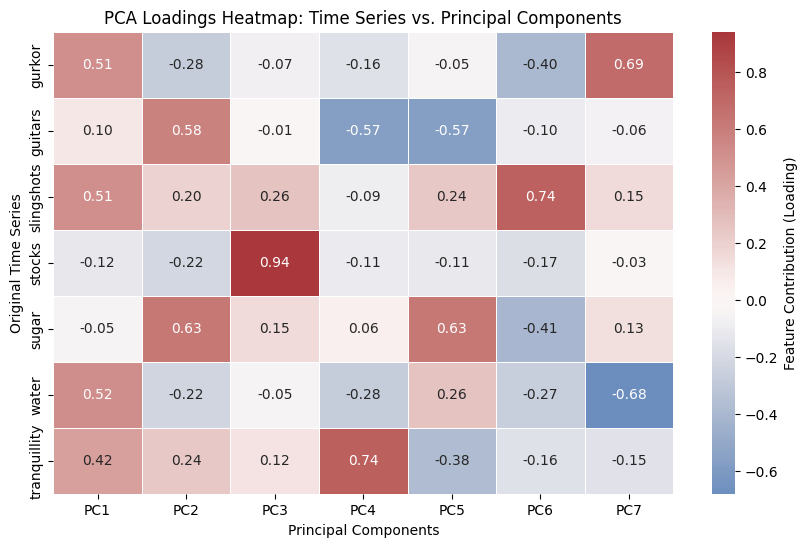

In [ ]:
import seaborn as sns

# ==========================================
# METHOD B: The Visual Heatmap (Highly Recommended)
# ==========================================
# This plots the entire loadings matrix. 
# Dark red means strong positive correlation with the PC.
# Dark blue means strong negative correlation with the PC.

plt.figure(figsize=(10, 6))
sns.heatmap(
    loadings_df, 
    annot=True,          # Prints the exact numbers inside the boxes
    cmap='vlag',         # A great diverging color map for -1 to 1 values
    center=0,            # Ensures 0 is strictly white/neutral
    fmt=".2f",           # Rounds to 2 decimal places
    linewidths=0.5, 
    cbar_kws={"label": "Feature Contribution (Loading)"}
)
plt.title('PCA Loadings Heatmap: Time Series vs. Principal Components')
plt.xlabel('Principal Components')
plt.ylabel('Original Time Series')
plt.show()

In [ ]:
df_returns = np.log(df_features / df_features.shift(1)).dropna()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_returns)

In [ ]:
pca = PCA()
principal_components = pca.fit_transform(scaled_data)

# Create a clean DataFrame of your new Principal Components, keeping your time index
component_names = [f"PC{i+1}" for i in range(principal_components.shape[1])]
df_pca_components = pd.DataFrame(
    data=principal_components, 
    index=df_returns.index, 
    columns=component_names
)

Explained Variance Ratio per Component:
PC1: 0.3429 (34.29%)
PC2: 0.1583 (15.83%)
PC3: 0.1400 (14.00%)
PC4: 0.1252 (12.52%)
PC5: 0.1184 (11.84%)
PC6: 0.0639 (6.39%)
PC7: 0.0512 (5.12%)

Cumulative Variance Explained by top 3 components: 64.13%


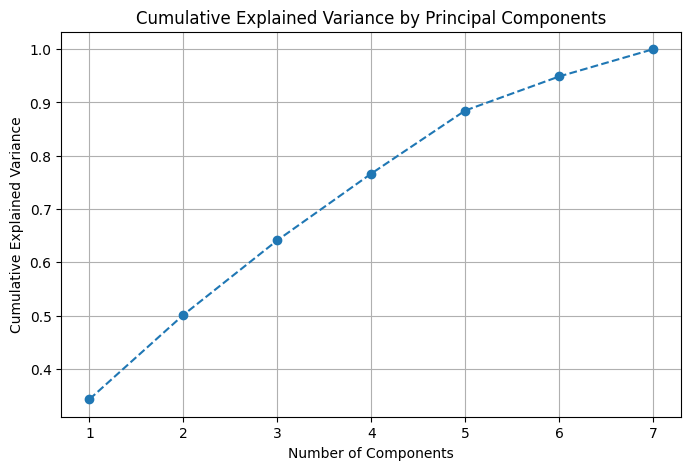

In [ ]:
# ==========================================
# 5. RECOMBINE METADATA WITH PCA RESULTS
# ==========================================
# Attach your 'index' and 'day' columns back to the principal components
df_final_pca = pd.concat([df_metadata, df_pca_components], axis=1)

# ==========================================
# 6. EVALUATE THE RESULTS
# ==========================================
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Explained Variance Ratio per Component:")
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")

print(f"\nCumulative Variance Explained by top 3 components: {cumulative_variance[2]*100:.2f}%")

# Optional: Plot the Scree Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, 8), cumulative_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by Principal Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

In [ ]:
# Extract the loadings
loadings = pd.DataFrame(
    pca.components_.T,  # Transpose the matrix
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=df_features.columns # Your original 7 column names
)

print("PCA Loadings (How much each series contributes to each PC):")
print(loadings)

PCA Loadings (How much each series contributes to each PC):
                   PC1       PC2       PC3       PC4       PC5       PC6  \
gurkor       -0.460177  0.432685  0.224346 -0.219547 -0.042253  0.363055   
guitars       0.494453  0.212433  0.094930 -0.257966 -0.238077  0.684623   
slingshots    0.441020  0.200992  0.092844 -0.490174 -0.346309 -0.558983   
stocks        0.045794 -0.373223  0.922390  0.086540 -0.008479 -0.015568   
sugar         0.202300  0.543136  0.134622  0.756202 -0.244054 -0.113503   
water        -0.469584  0.407874  0.205418 -0.239459 -0.099800 -0.259924   
tranquillity  0.292786  0.355817  0.144616 -0.091161  0.867185 -0.079592   

                   PC7  
gurkor       -0.607367  
guitars       0.330819  
slingshots   -0.289520  
stocks        0.000131  
sugar        -0.040837  
water         0.660358  
tranquillity  0.010116  


In [ ]:
# 1. Extract the raw loadings into a DataFrame
loadings_df = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(pca.n_components_)], 
    index=df_features.columns
)

In [ ]:
# ==========================================
# METHOD A: The "Human-Readable" Text Printout
# ==========================================
# This loops through your top 3 components and prints only the 
# time series that significantly drive that component.

print("=== PRINCIPAL COMPONENT DRIVERS ===")
# We only look at the top 3 PCs, as they usually contain the real signal
for pc in ['PC1', 'PC2', 'PC3']:
    print(f"\n{pc} is primarily driven by:")
    
    # Sort the features by their absolute contribution to this PC
    sorted_features = loadings_df[pc].abs().sort_values(ascending=False)
    
    for feature, abs_weight in sorted_features.items():
        actual_weight = loadings_df.loc[feature, pc]
        
        # Threshold: We only print features that have a meaningful impact (e.g., > 0.3)
        # Loadings are constrained between -1 and 1.
        if abs_weight > 0.25:
            direction = "🟢 Positive" if actual_weight > 0 else "🔴 Negative"
            print(f"  {feature:<15} | Weight: {actual_weight:>7.4f} | {direction}")

print("\n" + "="*35 + "\n")

=== PRINCIPAL COMPONENT DRIVERS ===

PC1 is primarily driven by:
  guitars         | Weight:  0.4945 | 🟢 Positive
  water           | Weight: -0.4696 | 🔴 Negative
  gurkor          | Weight: -0.4602 | 🔴 Negative
  slingshots      | Weight:  0.4410 | 🟢 Positive
  tranquillity    | Weight:  0.2928 | 🟢 Positive

PC2 is primarily driven by:
  sugar           | Weight:  0.5431 | 🟢 Positive
  gurkor          | Weight:  0.4327 | 🟢 Positive
  water           | Weight:  0.4079 | 🟢 Positive
  stocks          | Weight: -0.3732 | 🔴 Negative
  tranquillity    | Weight:  0.3558 | 🟢 Positive

PC3 is primarily driven by:
  stocks          | Weight:  0.9224 | 🟢 Positive




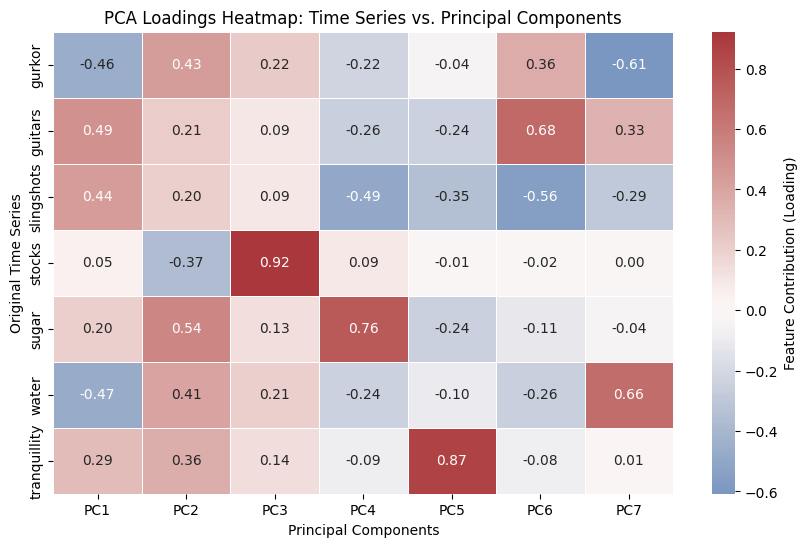

In [ ]:
import seaborn as sns

# ==========================================
# METHOD B: The Visual Heatmap (Highly Recommended)
# ==========================================
# This plots the entire loadings matrix. 
# Dark red means strong positive correlation with the PC.
# Dark blue means strong negative correlation with the PC.

plt.figure(figsize=(10, 6))
sns.heatmap(
    loadings_df, 
    annot=True,          # Prints the exact numbers inside the boxes
    cmap='vlag',         # A great diverging color map for -1 to 1 values
    center=0,            # Ensures 0 is strictly white/neutral
    fmt=".2f",           # Rounds to 2 decimal places
    linewidths=0.5, 
    cbar_kws={"label": "Feature Contribution (Loading)"}
)
plt.title('PCA Loadings Heatmap: Time Series vs. Principal Components')
plt.xlabel('Principal Components')
plt.ylabel('Original Time Series')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import orthogonal_procrustes
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# -------------------------------------------------
# 1. Load original data (your exact workflow)
# -------------------------------------------------
df_og = pd.read_csv('../data/spiff_data-2.csv')  # Adjust path as needed
df_og = df_og.replace(1000, np.nan)
df_original = df_og.drop(columns=['Unnamed: 0']).set_index('day')

# Calculate returns exactly as you did (simple returns Pt/Pt-1)
df_og_returns = (df_original.iloc[0:] / df_original.iloc[0:].shift(1)).dropna()

# Get the standard deviations of the original returns (for rescaling)
original_stds = df_og_returns.std()
print("Original returns standard deviations:")
print(original_stds)

# -------------------------------------------------
# 2. Your factor model parameters
# -------------------------------------------------
var_names = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']

Lambda_true = np.array([
    [-0.460493,  0.431975,  0.226305, -0.218470, -0.041653],
    [ 0.494112,  0.212170,  0.095774, -0.260540, -0.236640],
    [ 0.441043,  0.204170,  0.094476, -0.485899, -0.347878],
    [ 0.045350, -0.378985,  0.920457,  0.082476, -0.006300],
    [ 0.203079,  0.539617,  0.140728,  0.759331, -0.240474],
    [-0.469721,  0.408214,  0.206995, -0.237389, -0.099435],
    [ 0.292140,  0.353894,  0.144209, -0.092477,  0.868040]
])

Phi1 = np.array([
    [ 0.069570, -0.045041, -0.032271, -0.126121, -0.116237],
    [ 0.123517, -0.006882,  0.033199, -0.266336, -0.075593],
    [ 0.027233,  0.014420, -0.000103, -0.045385, -0.024730],
    [ 0.198330,  0.008947,  0.016066, -0.222132, -0.061226],
    [-0.032710, -0.032482,  0.001286,  0.015577, -0.016760]
])

Phi2 = np.array([
    [ 0.013774, -0.033803,  0.025312, -0.071823,  0.012382],
    [ 0.042048, -0.043486,  0.014998, -0.043731,  0.009972],
    [ 0.011989, -0.002305, -0.016781, -0.016861, -0.030828],
    [ 0.018717, -0.000719, -0.003339, -0.048658,  0.031319],
    [ 0.003668,  0.029666,  0.001740,  0.012825, -0.005191]
])

# -------------------------------------------------
# 3. Simulate VAR(2) factors
# -------------------------------------------------
np.random.seed(42)
T = 4000
burn = 500
F = np.zeros((T, 5))

for t in range(2, T):
    F[t] = Phi1 @ F[t-1] + Phi2 @ F[t-2] + np.random.randn(5)

F = F[burn:]  # Remove burn-in

# -------------------------------------------------
# 4. Generate observed series (standardized)
# -------------------------------------------------
# Project factors through loadings (this gives standardized returns)
Y_std = F @ Lambda_true.T
df_returns_std = pd.DataFrame(Y_std, columns=var_names)

# -------------------------------------------------
# 5. Rescale back to original return scale
# -------------------------------------------------
# Reverse z-score: r = r_z * σ (mean is ~0 for returns)
df_returns_sim = df_returns_std.multiply(original_stds.values, axis=1)

print("\nSimulated returns volatilities:")
print(df_returns_sim.std())

# -------------------------------------------------
# 6. Accumulate to price series (start at 100)
# -------------------------------------------------
start_value = 100
df_prices_sim = start_value + df_returns_sim.cumsum()

# Also get original prices for comparison (start at 100)
df_prices_original = start_value + df_og_returns.cumsum()

# -------------------------------------------------
# 7. Plot comparison
# -------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Simulated returns (rescaled)
df_returns_sim.plot(ax=axes[0,0], alpha=0.7, title='Simulated Returns (Rescaled)')
axes[0,0].axhline(0, color='black', linestyle='--', linewidth=0.5)
axes[0,0].set_ylabel('Return')

# Plot 2: Original returns
df_og_returns.plot(ax=axes[0,1], alpha=0.7, title='Original Returns')
axes[0,1].axhline(0, color='black', linestyle='--', linewidth=0.5)
axes[0,1].set_ylabel('Return')

# Plot 3: Simulated prices (cumsum)
df_prices_sim.plot(ax=axes[1,0], alpha=0.8, title='Simulated Price Paths (Start=100)')
axes[1,0].set_ylabel('Price Level')

# Plot 4: Original prices (cumsum)
df_prices_original.plot(ax=axes[1,1], alpha=0.8, title='Original Price Paths (Start=100)')
axes[1,1].set_ylabel('Price Level')

plt.tight_layout()
plt.show()

# -------------------------------------------------
# 8. Validation: Correlation between original and simulated
# -------------------------------------------------
# Note: Since we didn't align with Procrustes here yet, the factors might be 
# rotated. But the volatility structure should match.
print("\nVolatility comparison (Original vs Simulated):")
comparison = pd.DataFrame({
    'Original': original_stds,
    'Simulated': df_returns_sim.std(),
    'Ratio': df_returns_sim.std() / original_stds
})
print(comparison)